# 01 - Exploratory Audio Intelligence

This notebook starts the analytical journey by exploring the Spotify tracks dataset from a BI and Data Science perspective. The goal is to understand the available data, identify relevant audio patterns, and create the first insights that will later support clustering, classification, and recommendation.

## 1. Environment Setup

This first block imports the libraries used for data analysis and visualization. It also adds the project root to Python's path so the notebook can reuse functions from the `src` folder instead of duplicating logic inside the notebook.

In [1]:
import math
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.preprocessing import AUDIO_FEATURES, clean_tracks, load_tracks

sns.set_theme(style="whitegrid")

## 2. Load and Clean the Dataset

Here we load the raw CSV downloaded from KaggleHub and apply the first cleaning rules defined in `src/preprocessing.py`. Keeping cleaning logic in `src` makes the analysis reproducible and avoids rewriting the same transformations across notebooks.

In [2]:
tracks = clean_tracks(load_tracks(PROJECT_ROOT / "data" / "raw" / "dataset.csv"))
tracks.shape

(113549, 20)

## 3. Dataset Overview

This summary gives a first statistical view of the main audio features and the genre column. Numeric columns show metrics such as mean, standard deviation, quartiles, and maximum values. The categorical genre column shows how many genres exist and which one appears most frequently.

In [3]:
tracks[AUDIO_FEATURES + ["track_genre"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
popularity,113549.0,NaN,NaN,NaN,33.324433,22.283855,0.0,17.0,35.0,50.0,100.0
duration_ms,113549.0,NaN,NaN,NaN,228081.370844,106413.098525,8586.0,174184.0,213000.0,261588.0,5237295.0
explicit,113549.0,NaN,NaN,NaN,0.085584,0.27975,0.0,0.0,0.0,0.0,1.0
danceability,113549.0,NaN,NaN,NaN,0.567031,0.173409,0.0,0.456,0.58,0.695,0.985
energy,113549.0,NaN,NaN,NaN,0.642091,0.251053,0.0,0.473,0.685,0.854,1.0
loudness,113549.0,NaN,NaN,NaN,-8.243408,5.011422,-49.531,-9.998,-6.997,-5.001,4.532
speechiness,113549.0,NaN,NaN,NaN,0.084674,0.105762,0.0,0.0359,0.0489,0.0845,0.965
acousticness,113549.0,NaN,NaN,NaN,0.314064,0.331906,0.0,0.0168,0.168,0.596,0.996
instrumentalness,113549.0,NaN,NaN,NaN,0.155703,0.309217,0.0,0.0,0.000041,0.0487,1.0
liveness,113549.0,NaN,NaN,NaN,0.213613,0.190462,0.0,0.098,0.132,0.273,1.0


## 4. Feature Guide

Before comparing genres visually, it is useful to define what each selected feature represents. These variables will be used to create an audio profile for each genre.

In [ ]:
radar_feature_descriptions = pd.DataFrame(
    {
        "feature": ["tempo", "danceability", "energy", "speechiness", "valence", "liveness"],
        "short_description": [
            "Estimated speed of the song in beats per minute.",
            "How suitable the song is for dancing.",
            "Perceived intensity, activity, and power.",
            "Presence of spoken words or speech-like vocals.",
            "Emotional positivity, from darker to happier sound.",
            "Likelihood of a live performance or audience presence.",
        ],
    }
)

radar_feature_descriptions

## 5. Genre Distribution

Before comparing genres, we need to understand whether the dataset is balanced. A balanced genre distribution is useful for classification because the model is less likely to learn only the most frequent classes.

In [9]:
genre_counts = tracks["track_genre"].value_counts()
genre_counts.head(15)

track_genre
acoustic      1000
british       1000
country       1000
disco         1000
electronic    1000
emo           1000
funk          1000
garage        1000
indie-pop     1000
industrial    1000
j-rock        1000
mandopop      1000
metalcore     1000
mpb           1000
pagode        1000
Name: count, dtype: int64

## 6. Average Audio Profile by Genre

This table aggregates audio features by genre. It helps answer BI-style questions such as which genres are more energetic, more acoustic, more danceable, or more emotionally positive based on `valence`.

In [10]:
genre_audio_profile = (
    tracks.groupby("track_genre")[AUDIO_FEATURES]
    .mean()
    .sort_values("energy", ascending=False)
)

genre_audio_profile.head(10)

,popularity,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,,,,,
death-metal,32.179179,247519.217217,0.251251,0.368318,0.931468,-5.347288,0.111326,0.006702,0.275962,0.243355,0.247739,123.762797
grindcore,14.629259,133803.981964,0.153307,0.272077,0.924323,-6.238947,0.137612,0.008716,0.537692,0.280929,0.216354,119.268182
metalcore,43.477000,229006.573000,0.291000,0.423800,0.914485,-4.457694,0.110260,0.010286,0.045695,0.258180,0.314902,130.580195
happy,21.716717,242018.313313,0.126126,0.552697,0.910901,-5.416321,0.119794,0.057300,0.263466,0.284344,0.327686,152.920876
hardstyle,26.603206,225319.848697,0.096192,0.539411,0.901173,-4.347460,0.122448,0.051226,0.142170,0.257220,0.312074,146.905859
drum-and-bass,26.630522,278873.964859,0.026104,0.535734,0.876380,-4.164519,0.091718,0.025998,0.372373,0.220408,0.321753,155.254644
black-metal,22.461384,311018.401204,0.131394,0.296670,0.874721,-6.528497,0.087169,0.027137,0.441996,0.241119,0.192131,128.592122
heavy-metal,26.179359,252021.588176,0.083166,0.428429,0.874152,-5.746255,0.074556,0.014983,0.082473,0.279830,0.388250,126.611729
party,21.033199,201052.210262,0.044266,0.667157,0.871349,-4.411034,0.087397,0.092450,0.001697,0.287667,0.681179,131.323091


## 7. Genre Radar Atlas

Radar charts are useful here because they show the "shape" of each genre across multiple audio dimensions at once. To make features comparable, `tempo` is normalized between 0 and 1, while the other selected Spotify features already use a 0 to 1 scale.

The grid is paginated because the dataset has 114 genres. This keeps the visual readable while still allowing every genre to be explored by changing the `page` parameter.

In [11]:
radar_features = ["tempo", "danceability", "energy", "speechiness", "valence", "liveness"]

radar_profile = tracks.groupby("track_genre")[radar_features].mean()
radar_profile["tempo"] = (
    radar_profile["tempo"] - radar_profile["tempo"].min()
) / (radar_profile["tempo"].max() - radar_profile["tempo"].min())

all_genres = sorted(radar_profile.index)
genres_per_page = 24
page = 1

start = (page - 1) * genres_per_page
end = start + genres_per_page
selected_genres = all_genres[start:end]

radar_profile.loc[selected_genres]

,tempo,danceability,energy,speechiness,valence,liveness
track_genre,,,,,,
acoustic,0.486884,0.549593,0.435368,0.043247,0.424023,0.153244
afrobeat,0.490161,0.669408,0.702938,0.086622,0.698475,0.184724
alt-rock,0.566785,0.534601,0.754027,0.055076,0.518179,0.210340
alternative,0.532147,0.559963,0.719848,0.070134,0.495158,0.201441
ambient,0.375690,0.367966,0.237257,0.041553,0.167345,0.129298
anime,0.551144,0.537517,0.673788,0.087296,0.434636,0.197319
black-metal,0.622532,0.296670,0.874721,0.087169,0.192131,0.241119
bluegrass,0.594621,0.534772,0.530287,0.038690,0.634855,0.226550
blues,0.453222,0.568537,0.582046,0.063942,0.603439,0.191839


## 8. Radar Chart Grid

Each chart below represents the average audio identity of a genre. Wider shapes indicate stronger presence of those characteristics. For example, a genre with high `energy` and high normalized `tempo` tends to sound more intense and fast-paced, while high `valence` suggests a more positive emotional tone.

To inspect all genres, change `page` in the previous cell. With 24 genres per page, this dataset can be explored across five pages.

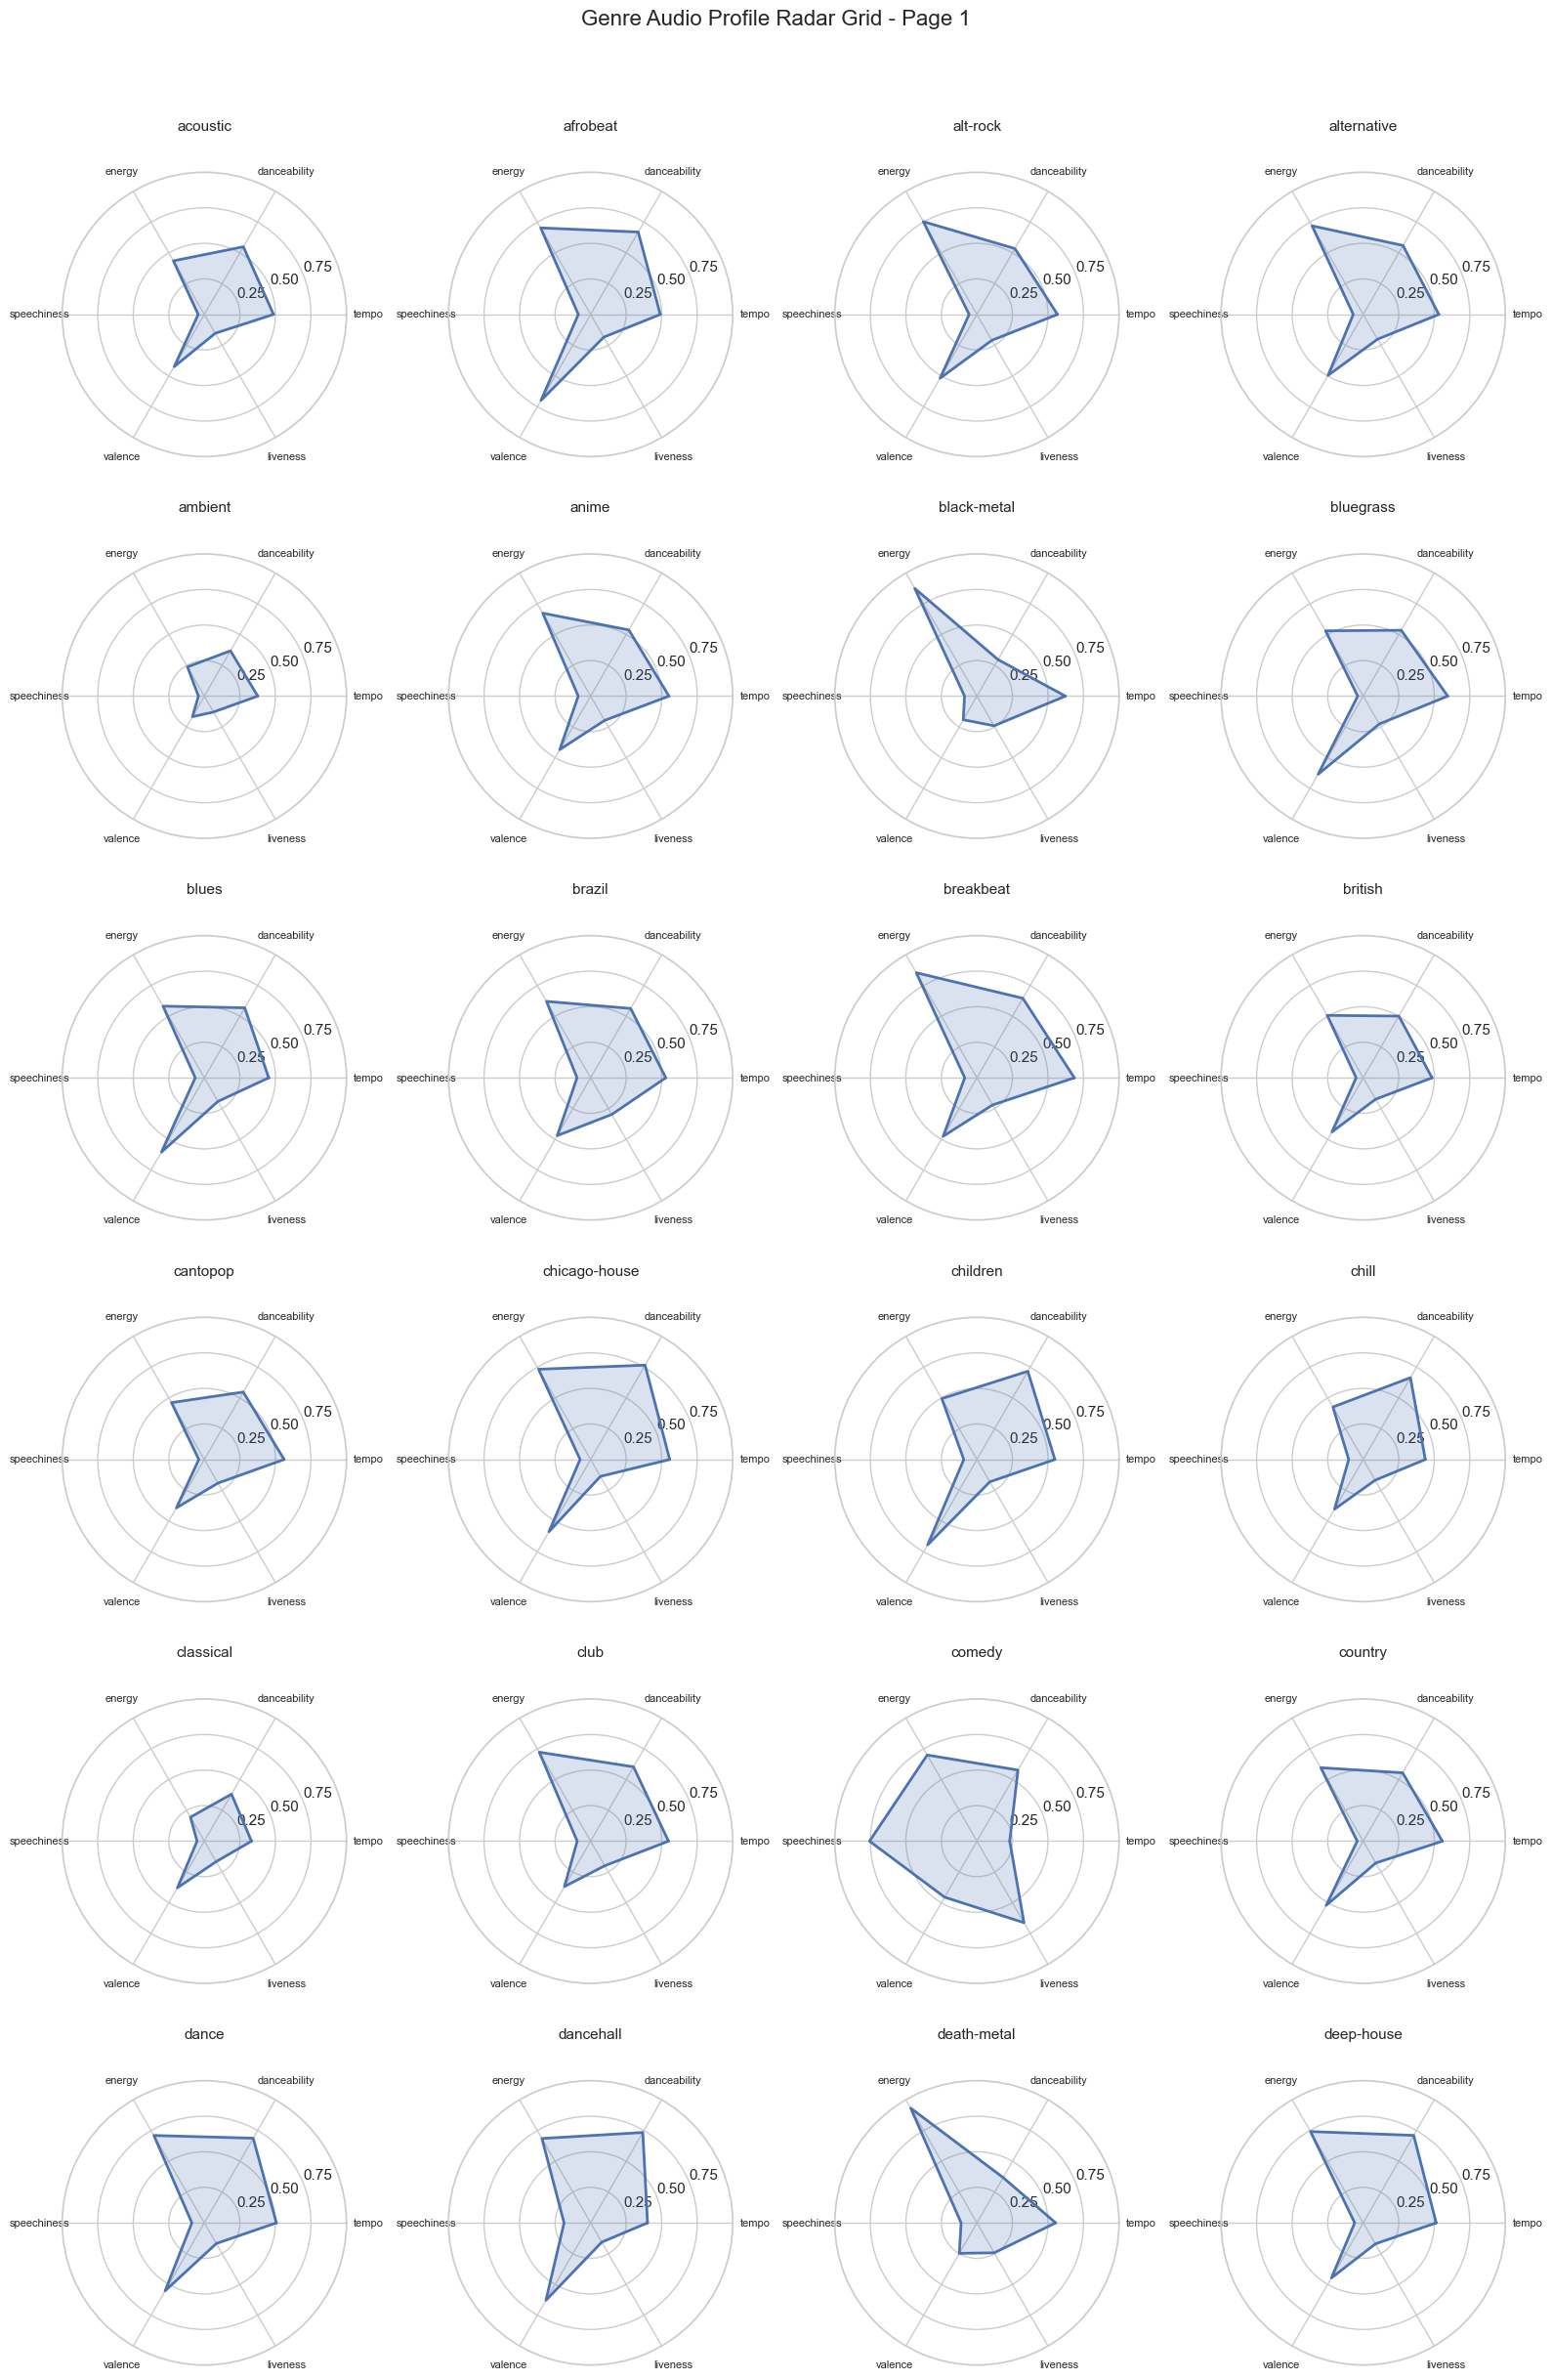

In [14]:
labels = radar_features
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

n_cols = 4
n_rows = math.ceil(len(selected_genres) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), subplot_kw={"polar": True})
axes = np.array(axes).reshape(-1)

for ax, genre in zip(axes, selected_genres):
    values = radar_profile.loc[genre, labels].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.2)
    ax.set_title(genre, y=1.12, fontsize=11)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks([0.25, 0.50, 0.75])
    ax.set_ylim(0, 1)

for ax in axes[len(selected_genres):]:
    ax.axis("off")

fig.suptitle(f"Genre Audio Profile Radar Grid - Page {page}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()